In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [6]:
# Load Dataset

data = pd.read_csv("winequality.csv")
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [9]:
print("Dataset Size =",data.shape)
print("Columns =",data.columns.to_list)
print("Missing Values ",data.isnull().sum())

Dataset Size = (1599, 12)
Columns = <bound method IndexOpsMixin.tolist of Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')>
Missing Values  fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [12]:
# Features and Target

X = data.drop("quality", axis=1)     # Features 11 Column
y = data["quality"]                  # Target

In [13]:
# Standardize the feature

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
# Apply PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance Ratio = ",pca.explained_variance_ratio_)
print("Total Variance Explained = ",sum(pca.explained_variance_ratio_))

Variance Ratio =  [0.28173931 0.1750827 ]
Total Variance Explained =  0.4568220118429404


TypeError: 'str' object is not callable

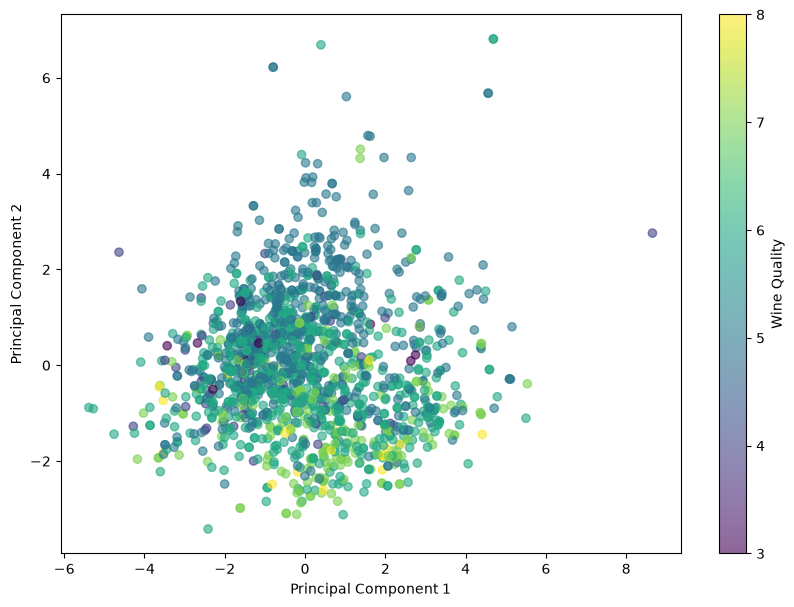

In [34]:
#Visualize PCA

plt.figure(figsize=(10,7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:,1], c=y, cmap="viridis", alpha=0.6)
plt.colorbar(scatter, label="Wine Quality")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Of Wine Quality")
plt.show()

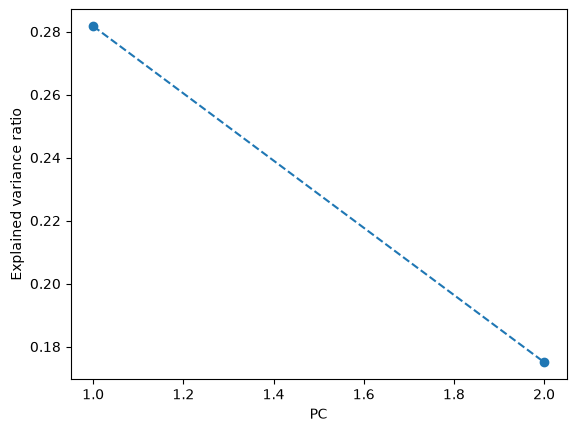

In [35]:
# Scree Plot -> Variance per component

plt.plot(range(1,3),pca.explained_variance_ratio_,marker="o",linestyle="--")
plt.xlabel('PC')
plt.ylabel("Explained variance ratio")
plt.title=("Scree Plot")
plt.show()

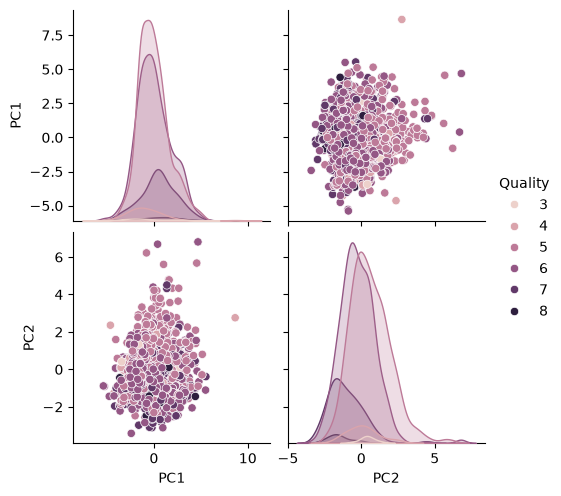

In [26]:
# Pair Plot

pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["Quality"] = y

sns.pairplot(pca_df, hue="Quality")
plt.show()

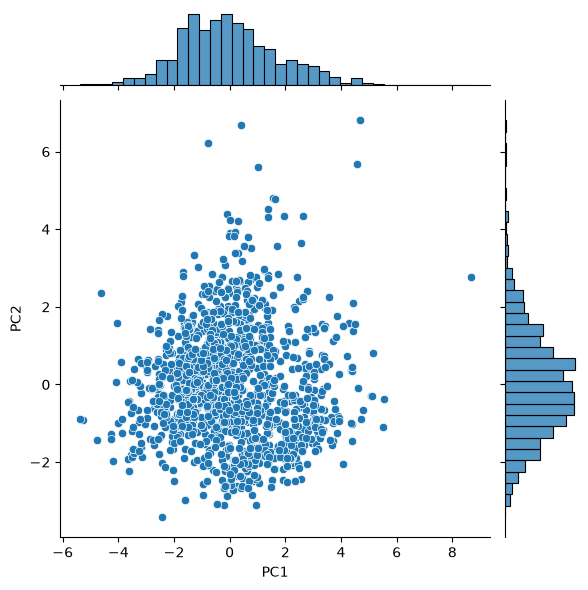

In [31]:
# Joint PLot

pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])

sns.jointplot(data=pca_df, x="PC1", y="PC2", kind="scatter")
plt.show()

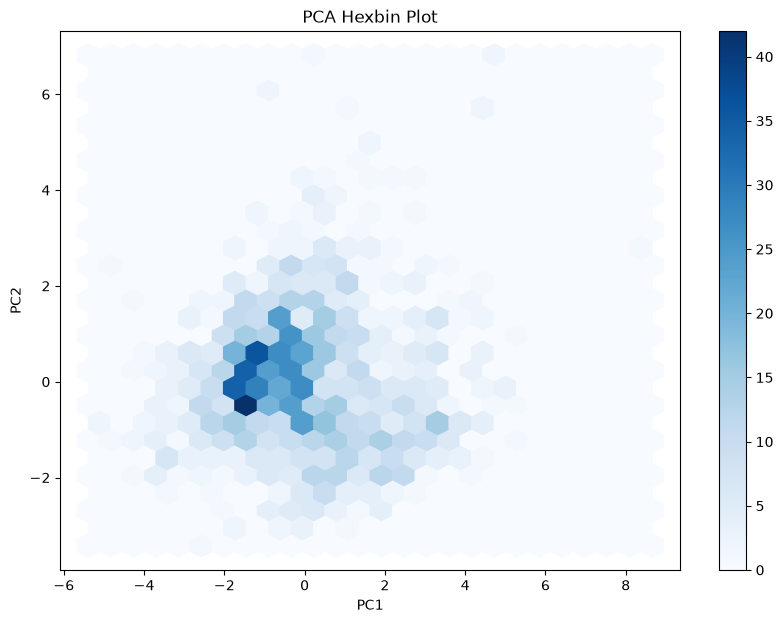

In [27]:
# Hexbin Plot

plt.figure(figsize=(10,7))
plt.hexbin(X_pca[:,0], X_pca[:,1], gridsize=25, cmap="Blues")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Hexbin Plot")
plt.colorbar()
plt.show()

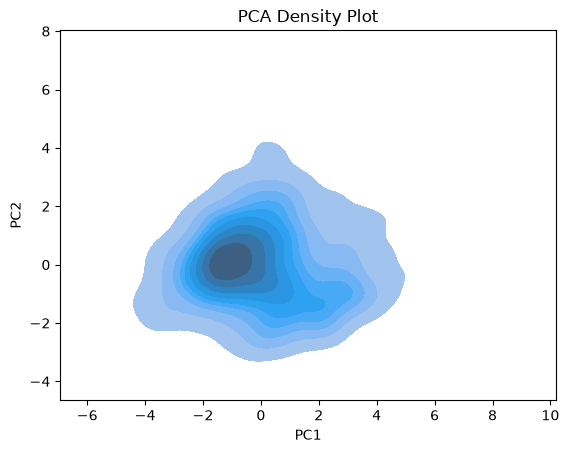

In [32]:
# Density (KDE) Plot

pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])

sns.kdeplot(data=pca_df, x="PC1", y="PC2", fill=True)
plt.title("PCA Density Plot")
plt.show()

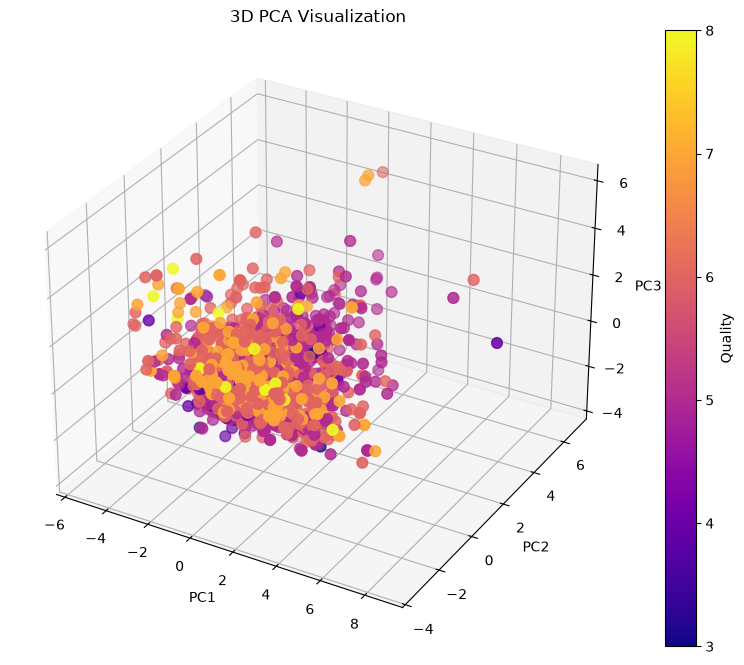

In [39]:
# 3D PCA Plot

from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=y,
    cmap='plasma',
    s=60
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA Visualization")

plt.colorbar(scatter, label="Quality")
plt.show()

In [58]:
# Train a classification after PCA

X_train , X_test , y_train , y_test = train_test_split(X_pca,y,test_size=0.2,random_state=41)
clf = RandomForestClassifier (random_state=42)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy PCA =",accuracy)


# Compare with original feature

X_train_o , X_test_o , y_train_o , y_test_o = train_test_split(X_scaled,y,test_size=0.2,random_state=41)
clf = RandomForestClassifier (random_state=42)
clf.fit(X_train_o,y_train_o)
y_pred_o = clf.predict(X_test_o)
accuracy_o = accuracy_score(y_test_o,y_pred_o)
print("Original Accuracy =",accuracy_o)

Accuracy PCA = 0.653125
Original Accuracy = 0.703125
